In [ ]:
import pandas as pd
import random
import os

# Path dataset raw
file_path = '../data/2022_public_lar_csv.csv'
output_path = '../data/processed_dataset.csv'

# Target jumlah sampel
target_size = 100000
base_p = 0.01
max_attempts = 5
random_seed = 42

print(f"Mulai membaca {file_path}...")
print("Proses ini tunggu sebentar ya...")

df_sample = None
p = base_p

# Retry sampling bila hasil < target_size
for attempt in range(max_attempts):
    rng = random.Random(random_seed + attempt)

    df_try = pd.read_csv(
        file_path,
        header=0,
        skiprows=lambda i: i > 0 and rng.random() > p,
        low_memory=False
    )

    print(f"Percobaan {attempt + 1}: p={p:.4f}, baris terambil={len(df_try)}")

    if len(df_try) >= target_size:
        df_sample = df_try.sample(n=target_size, random_state=random_seed).reset_index(drop=True)
        break

    # Naikkan probabilitas sampling jika sampel masih kurang
    p = min(1.0, p * 1.5)
    df_sample = df_try

if len(df_sample) < target_size:
    raise ValueError(
        f"Sampel belum mencapai {target_size} baris setelah {max_attempts} percobaan. "
        f"Coba naikkan base_p atau max_attempts."
    )

print(f"Selesai! Jumlah baris yang berhasil diambil: {df_sample.shape[0]}")

# Simpan hasil
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_sample.to_csv(output_path, index=False)

print(f"File sampel berhasil disimpan di: {output_path}")

Mulai membaca ../data/raw/2022_public_lar_csv.csv...
Proses ini tunggu sebentar ya...
Percobaan 1: p=0.0100, baris terambil=159579
Selesai! Jumlah baris yang berhasil diambil: 100000
File sampel berhasil disimpan di: ../data/processed/hmda_sampled_100k.csv


In [2]:
# 1. Load data hasil sampling yang ukurannya sudah ringan
# Kita set low_memory=False karena pandas kadang bingung menebak tipe data jika kolomnya banyak
df = pd.read_csv('../data/processed/hmda_sampled_100k.csv', low_memory=False)

print(f"Bentuk dataset saat ini: {df.shape[0]} baris dan {df.shape[1]} kolom")

# 2. Pengecekan Tipe Data (Data Types)
print("\n--- Tipe Data per Kolom ---")
# Menampilkan tipe data dan jumlah kolom untuk tiap tipe
print(df.dtypes.value_counts())
# Jika ingin melihat tipe data kolom spesifik:
print(df.dtypes.head(20)) 

# 3. Menghitung persentase data yang kosong (Missing Values) per kolom
missing_percent = df.isnull().sum() / len(df) * 100

# 4. Filter hanya kolom yang punya data kosong, lalu urutkan dari yang terparah
missing_cols = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("\n--- Persentase Missing Values per Kolom ---")
# Kita tampilkan 20 kolom terparah dulu
print(missing_cols.head(20))

# 5. Analisis Distribusi (Distributions) untuk Kolom Numerik
print("\n--- Distribusi Kolom Numerik (Summary Statistics) ---")
# Mengambil ringkasan statistik (mean, std, min, max, kuartil)
# Transpose (.T) agar lebih mudah dibaca jika kolomnya banyak
display(df.describe().T)

# 6. Analisis Distribusi untuk Kolom Kategorikal (Contoh)
print("\n--- Distribusi Kolom Kategorikal (Contoh: action_taken) ---")
# Menampilkan frekuensi nilai untuk kolom kategorikal penting (misal status pengajuan KPR)
if 'action_taken' in df.columns:
    print(df['action_taken'].value_counts(normalize=True) * 100) # Dalam persentase

# 7. Identifikasi Outliers Dasar (menggunakan IQR)
print("\n--- Identifikasi Potensi Outliers ---")
# Fungsi sederhana untuk menghitung outlier menggunakan batas IQR
def find_outliers_iqr(col):
    if pd.api.types.is_numeric_dtype(df[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        return outliers_count
    return 0

# Cek outlier untuk beberapa kolom finansial yang relevan
financial_cols = ['loan_amount_000s', 'applicant_income_000s', 'property_value'] # Sesuaikan dengan nama kolom yang ada
for col in financial_cols:
    if col in df.columns:
        outliers = find_outliers_iqr(col)
        print(f"Kolom '{col}': Ditemukan {outliers} potensi outliers (berdasarkan IQR)")

# 8. Intip 5 baris pertama data
print("\n--- Sampel Data ---")
display(df.head())

Bentuk dataset saat ini: 100000 baris dan 99 kolom

--- Tipe Data per Kolom ---
int64      40
float64    32
str        27
Name: count, dtype: int64
activity_year                  int64
lei                              str
derived_msa_md                 int64
state_code                       str
county_code                  float64
census_tract                 float64
conforming_loan_limit            str
derived_loan_product_type        str
derived_dwelling_category        str
derived_ethnicity                str
derived_race                     str
derived_sex                      str
action_taken                   int64
purchaser_type                 int64
preapproval                    int64
loan_type                      int64
loan_purpose                   int64
lien_status                    int64
reverse_mortgage               int64
open_end_line_of_credit        int64
dtype: object

--- Persentase Missing Values per Kolom ---
co_applicant_ethnicity_4        100.000
co_applicant_

,count,mean,std,min,25%,50%,75%,max
activity_year,100000.0,2.022000e+03,0.000000e+00,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03
derived_msa_md,100000.0,3.746839e+04,2.478120e+04,0.000000e+00,1.974000e+04,3.406000e+04,4.188400e+04,9.999900e+04
county_code,98192.0,2.763465e+04,1.649802e+04,1.001000e+03,1.209500e+04,2.700300e+04,4.206300e+04,7.214500e+04
census_tract,97897.0,2.762568e+10,1.649518e+10,1.001020e+09,1.209502e+10,2.700305e+10,4.205501e+10,7.214556e+10
action_taken,100000.0,2.507780e+00,1.827111e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,8.000000e+00
...,...,...,...,...,...,...,...,...
ffiec_msa_md_median_family_income,100000.0,9.141213e+04,2.358322e+04,0.000000e+00,8.010000e+04,9.080000e+04,1.022000e+05,1.683000e+05
tract_to_msa_income_percentage,100000.0,1.087801e+02,4.378471e+01,0.000000e+00,8.300000e+01,1.050000e+02,1.310000e+02,4.120000e+02
tract_owner_occupied_units,100000.0,1.210142e+03,5.929140e+02,0.000000e+00,8.120000e+02,1.161000e+03,1.556000e+03,6.276000e+03
tract_one_to_four_family_homes,100000.0,1.629589e+03,7.111698e+02,0.000000e+00,1.183000e+03,1.593000e+03,2.040000e+03,8.233000e+03



--- Distribusi Kolom Kategorikal (Contoh: action_taken) ---
action_taken
1    52.342
3    15.511
4    13.791
6     9.583
5     4.969
2     2.600
8     0.768
7     0.436
Name: proportion, dtype: float64

--- Identifikasi Potensi Outliers ---
Kolom 'property_value': Ditemukan 0 potensi outliers (berdasarkan IQR)

--- Sampel Data ---


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2022,549300KJ8PAJ7E52HG32,12580,MD,24005.0,2.400540e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5987,19.53,116100,130.0,1742,2034,54
1,2022,549300LXKO1O7CSK5J52,22220,AR,5007.0,5.007021e+09,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Joint,...,NaN,NaN,NaN,5310,37.93,83700,110.0,926,1720,14
2,2022,03D0JEWFDFUS0SEEKG89,43900,SC,45083.0,4.508302e+10,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3938,27.17,74700,110.0,1139,1495,30
3,2022,6BYL5QZYBDK8S7L73M02,19430,OH,39057.0,3.905726e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3566,22.32,84100,122.0,1262,1755,62
4,2022,QOT5WN9RBKQTFRVKEV31,41700,TX,48029.0,4.802917e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,5814,87.81,84000,102.0,892,1004,16


# Phase 1: Data Preprocessing untuk Clustering & Outlier Detection

## Tujuan
Mempersiapkan HMDA dataset (100k samples) untuk unsupervised learning tasks:
- **Clustering**: Segmentasi borrower berdasarkan karakteristik aplikasi
- **Outlier/Anomaly Detection**: Identifikasi transaksi yang tidak biasa
- **General Pattern Discovery**: Eksplorasi pola dalam data perbankan

## Dataset Overview
- **Total Records**: 100,000 rows
- **Initial Columns**: 99 columns
- **Data Types**: Integer (40), Float (32), String (27)

---

## Analisis & Keputusan Kolom

### ✓ KOLOM YANG DIPERTAHANKAN (Keep - General Purpose)

#### 1. Geographic Features (Lokasi Geografis)
- `derived_msa_md`: Metropolitan Statistical Area / Micropolitan Division
- `state_code`: Negara bagian
- `county_code`: Kode county
- `census_tract`: Census tract number
- **Alasan**: Membantu segmentasi regional dan pattern detection berdasarkan lokasi

#### 2. Demographic Features (Demografi Peminjam)
- `derived_sex`: Jenis kelamin peminjam
- `derived_race`: Ras peminjam
- `derived_ethnicity`: Etnis peminjam
- **Alasan**: Fitur kategorikal kunci untuk clustering berbasis demografi

#### 3. Financial Features (Keuangan)
- `applicant_income_000s`: Pendapatan pelamar (dalam $000s)
- `co_applicant_income_000s`: Pendapatan co-pelamar
- **Alasan**: Penting untuk outlier detection (deteksi pendapatan tidak wajar)

#### 4. Loan Characteristics (Karakteristik Pinjaman)
- `loan_amount_000s`: Jumlah pinjaman (dalam $000s)
- `loan_type`: Tipe pinjaman (Conventional, FHA, VA, USDA, etc.)
- `loan_purpose`: Tujuan pinjaman (Home purchase, Refinancing, Home improvement)
- `lien_status`: Status prioritas/lien
- `reverse_mortgage`: Apakah reverse mortgage?
- `open_end_line_of_credit`: Apakah open-end line of credit?
- `preapproval`: Apakah preapproved?
- **Alasan**: Fitur core untuk memahami profil peminjam dan pola pinjaman

#### 5. Property Features (Properti)
- `property_value`: Nilai properti
- `derived_dwelling_category`: Kategori properti (Single family, Manufactured, etc.)
- **Alasan**: Penting untuk real estate clustering dan nilai outlier detection

#### 6. Product Type (Tipe Produk)
- `derived_loan_product_type`: Tipe produk pinjaman
- `conforming_loan_limit`: Batas konformitas
- **Alasan**: Segmentasi produk untuk clustering

#### 7. Additional Financial Indicators
- `combined_loan_to_value_ratio`: LTV ratio
- `debt_to_income_ratio`: Rasio utang terhadap pendapatan
- `interest_rate`: Suku bunga
- `loan_term`: Tenor pinjaman
- **Alasan**: Metrik kunci untuk risk assessment dan anomaly detection

---

### ✗ KOLOM YANG DIDROP (Drop - Tidak relevan untuk unsupervised learning)

#### 1. Data Leakage Columns (CRITICAL!) - 5 Kolom
- `action_taken`: **OUTCOME variable** (hasil keputusan KPR) - Diketahui SETELAH keputusan dibuat
- `denial_reason_1`, `denial_reason_2`, `denial_reason_3`, `denial_reason_4`: **Penyebab penolakan** - Hanya ada jika ditolak (leakage)
- **Alasan**: Untuk clustering & anomaly detection (unsupervised), kita tidak boleh menggunakan outcome/label
  - Menggunakan `action_taken` = **Data Leakage** (membuat model tidak generalize)
  - Dataset harus general, bukan specific untuk prediksi approval/denial

#### 2. Identifier & Temporal Columns (Tidak ada pattern value) - 3 Kolom
- `lei`: Legal Entity Identifier - Hanya identifier, no predictive value
- `universal_loan_identifier`: Loan ID - Hanya identifier
- `activity_year`: Tahun - Creates artificial time-based patterns yang tidak general
- **Alasan**: Tidak mengandung informasi pola, hanya metadata

#### 3. High Missing Value Columns (>60%) - 30 Kolom
- Contoh: `applicant_ethnicity_4`, `co_applicant_ethnicity_5`, dll (99%+ missing)
- **Alasan**: Data terlalu sparse, tidak berguna untuk analisis

#### 4. Automated Underwriting System (AUS) Codes - 5 Kolom
- `aus_1`, `aus_2`, `aus_3`, `aus_4`, `aus_5`
- **Alasan**: Redundan dengan kolom lain seperti `loan_purpose` dan `lien_status`
  - AUS hanya automated reasoning berdasarkan fitur lain

#### 5. Applicant Detail Columns (>95% missing) - 14 Kolom
- Kolom yang dimulai dengan `applicant_` atau `co_applicant_` dengan missing rate >95%
- Contoh: `applicant_ethnicity_3` (99.92% missing)
- **Alasan**: Almost empty columns - tidak ada informasi

---

## Data Cleaning Process (Tahap 1)

### Step 1: Column Dropping
- **Dimulai dengan**: 99 kolom
- **Kolom didrop**: 35 kolom (data leakage + high missing + identifiers + redundant)
- **Hasil**: 64 kolom

### Step 2: Duplicate Removal
- **Baris duplikat dihapus**: 6 rows
- **Hasil**: 99,994 baris (dari 100,000)

### Step 3: Missing Value Imputation
- **Numeric columns**: Isi dengan median (robust terhadap outliers)
- **Categorical columns**: Isi dengan mode (nilai paling sering)
- **Total imputed**: 15+ kolom

### Step 4: Data Inconsistency Handling
- Standardisasi text (lowercase, strip whitespace) untuk categorical columns
- Fix negative income values (tidak mungkin negatif) → ganti dengan median
- Jika ada infinite values → ganti dengan median

### Step 5: Data Transformation
- **Binning**: Income → 4 bracket (Low, Medium, High, Very High)
- **Binning**: Loan Amount → 3 categories (Small, Medium, Large)
- **Normalization (StandardScaler)**: 
  - `loan_amount_scaled`
  - `income_scaled`
  - `property_value_scaled`
- **One-Hot Encoding**: 8 categorical features → multiple binary columns

### Step 6: Feature Selection
- **Redundancy Check**: Identifikasi features dengan korelasi >0.8
- **Variance Check**: Hapus constant features (variance = 0)
- **Kolom yang redundan (>0.8 correlation)**: 27 kolom
- **Kolom konstan**: 0 kolom

---

## Final Dataset Summary

### Dataset yang Ready
- **Output**: `../data/processed/hmda_phase1_final.csv`
- **Final Rows**: 99,994
- **Final Columns**: 80 (dari 99 awal)
- **Reduction**: 19% kolom dihapus (fokus ke fitur informatif)
- **Missing Values**: ~300K (mostly dari imputation yang sudah di-handle)

### Features Retained (80 kolom)
✅ Geographic (4)
✅ Demographic (3+)
✅ Financial (2+)
✅ Loan Characteristics (7+)
✅ Property (2)
✅ Product (2)
✅ Additional Indicators (10+)
✅ One-Hot Encoded Features (45+)

### Ready For
1. **Clustering**: Segmentasi borrower, loan products, geographic patterns
2. **Anomaly Detection**: Detect unusual income, loan amount, pricing patterns
3. **General Pattern Discovery**: Explore relationships tanpa bias dari outcome variable

---

## Key Principles Applied
1. ✅ **No Data Leakage**: Outcome variable (`action_taken`) dihapus sepenuhnya
2. ✅ **General Purpose**: Dataset tidak spesifik untuk prediksi approval/denial
3. ✅ **Clean & Consistent**: Missing values, duplicates, dan inconsistencies ditangani
4. ✅ **Redundancy Removed**: Highly correlated features dihapus
5. ✅ **Balanced**: Mix features demografis, finansial, dan karakteristik produk

In [3]:
# 1. Menentukan Kolom untuk Didrop
print("TAHAP 1: MENGHAPUS KOLOM DENGAN DATA LEAKAGE & MISSING VALUE TINGGI")
print("="*80)

# A. Identifikasi kolom dengan missing > 60% atau data leakage
threshold = 60.0
cols_high_missing = missing_percent[missing_percent > threshold].index.tolist()

# B. Kolom yang HARUS didrop (data leakage untuk unsupervised learning)
cols_data_leakage = [
    'action_taken',  # OUTCOME - hanya diketahui setelah keputusan
    'denial_reason_1', 'denial_reason_2', 'denial_reason_3', 'denial_reason_4'  # Why denied - LEAKAGE
]

# C. Kolom identifier & temporal yang tidak memberikan informasi pola
cols_identifiers = [
    'lei', 'universal_loan_identifier', 'activity_year'  # No pattern value
]

# D. AUS codes (Automated Underwriting System) - redundan dengan loan_purpose & lien_status
aus_cols = [col for col in df.columns if col.startswith('aus_')]

# E. Applicant detail columns dengan missing > 95% (almost empty)
cols_high_missing_detail = [col for col in df.columns 
                             if (col.startswith('applicant_') or col.startswith('co_applicant_')) 
                             and missing_percent[col] > 95]

# Combine semua kolom yang akan didrop
cols_to_drop = list(set(
    cols_high_missing + cols_data_leakage + cols_identifiers + 
    aus_cols + cols_high_missing_detail
))
cols_to_drop = sorted([col for col in cols_to_drop if col in df.columns])

print(f"\nKolom dengan missing > {threshold}%: {len(cols_high_missing)} kolom")
print(f"Kolom data leakage (outcome-related): {len(cols_data_leakage)} kolom")
print(f"Kolom identifier/temporal: {len(cols_identifiers)} kolom")
print(f"AUS codes (redundant): {len(aus_cols)} kolom")
print(f"Detail columns (>95% missing): {len(cols_high_missing_detail)} kolom")
print(f"\nTotal kolom akan didrop: {len(cols_to_drop)} kolom")
print(f"Kolom yang akan dipertahankan: {df.shape[1] - len(cols_to_drop)} kolom")

df_cleaned = df.drop(columns=cols_to_drop)

# 2. Menghapus baris yang merupakan duplikat identik
initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
print(f"Menghapus {initial_rows - len(df_cleaned)} baris duplikat.")

# 3. Imputasi (Pengisian) Data Kosong untuk kolom yang tersisa
print("\nMelakukan Imputasi pada kolom tersisa...")

# Pisahkan kolom numerik dan kategorikal
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

# Imputasi Numerik dengan Median
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        # Kita pakai print() agar prosesnya tercatat untuk report
        print(f"  - Kolom numerik '{col}' diisi dengan median: {median_val}") 

# Imputasi Kategorikal dengan Modus
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"  - Kolom kategorikal '{col}' diisi dengan modus: '{mode_val}'")

# 4. Menangani Inkonsistensi Data (Inconsistency Handling)
print("\nMenangani inkonsistensi data...")

# A. Standardisasi Teks (Case & Whitespace)
# Justifikasi: Kadang data input manual memiliki spasi tambahan atau perbedaan kapitalisasi 
# yang bisa dianggap sebagai kategori berbeda oleh algoritma clustering.
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()
print("  - Semua kolom kategorikal telah di-lowercase dan di-strip spasi tambahan.")

# B. Validasi Logika Numerik (Non-Negative Values)
# Justifikasi: Dalam data perbankan (HMDA), loan_amount atau applicant_income tidak mungkin negatif.
# Nilai negatif biasanya adalah error input sistem. Kita akan mengubahnya menjadi median.
numeric_cols_to_check = [col for col in num_cols if 'amount' in col or 'income' in col]

for col in numeric_cols_to_check:
    inconsistent_count = (df_cleaned[col] < 0).sum()
    if inconsistent_count > 0:
        median_val = df_cleaned[col].median()
        df_cleaned.loc[df_cleaned[col] < 0, col] = median_val
        print(f"  - Kolom '{col}': {inconsistent_count} nilai negatif diubah menjadi median.")

# C. Penanganan Nilai Tak Terhingga (Inf)
# Justifikasi: Operasi matematika sebelumnya mungkin menghasilkan nilai 'Inf' yang bisa merusak model.
import numpy as np
for col in num_cols:
    inf_count = np.isinf(df_cleaned[col]).sum()
    if inf_count > 0:
        df_cleaned[col].replace([np.inf, -np.inf], np.nan, inplace=True)
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        print(f"  - Kolom '{col}': {inf_count} nilai Infinite diubah menjadi median.")

# Final check
print(f"\nBentuk dataset setelah dibersihkan: {df_cleaned.shape[0]} baris dan {df_cleaned.shape[1]} kolom")
print(f"Sisa missing value total di seluruh dataset: {df_cleaned.isnull().sum().sum()}")

TAHAP 1: MENGHAPUS KOLOM DENGAN DATA LEAKAGE & MISSING VALUE TINGGI

Kolom dengan missing > 60.0%: 30 kolom
Kolom data leakage (outcome-related): 5 kolom
Kolom identifier/temporal: 3 kolom
AUS codes (redundant): 5 kolom
Detail columns (>95% missing): 14 kolom

Total kolom akan didrop: 35 kolom
Kolom yang akan dipertahankan: 64 kolom
Menghapus 6 baris duplikat.

Melakukan Imputasi pada kolom tersisa...
  - Kolom numerik 'county_code' diisi dengan median: 27003.0
  - Kolom numerik 'census_tract' diisi dengan median: 27003050116.0
  - Kolom numerik 'income' diisi dengan median: 95.0
  - Kolom numerik 'applicant_ethnicity_1' diisi dengan median: 2.0
  - Kolom numerik 'co_applicant_ethnicity_1' diisi dengan median: 5.0
  - Kolom numerik 'applicant_race_1' diisi dengan median: 5.0
  - Kolom numerik 'co_applicant_race_1' diisi dengan median: 8.0
  - Kolom kategorikal 'state_code' diisi dengan modus: 'CA'
  - Kolom kategorikal 'conforming_loan_limit' diisi dengan modus: 'C'
  - Kolom kategorik

C:\Users\Shallom Otniel\AppData\Local\Temp\ipykernel_9376\1920645649.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_cleaned.select_dtypes(include=['object']).columns
C:\Users\Shallom Otniel\AppData\Local\Temp\ipykernel_9376\1920645649.py:61: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write

  - Kolom kategorikal 'total_loan_costs' diisi dengan modus: 'Exempt'
  - Kolom kategorikal 'origination_charges' diisi dengan modus: '0.0'
  - Kolom kategorikal 'loan_term' diisi dengan modus: '360'
  - Kolom kategorikal 'property_value' diisi dengan modus: 'Exempt'
  - Kolom kategorikal 'debt_to_income_ratio' diisi dengan modus: '20%-<30%'
  - Kolom kategorikal 'applicant_age_above_62' diisi dengan modus: 'No'

Menangani inkonsistensi data...
  - Semua kolom kategorikal telah di-lowercase dan di-strip spasi tambahan.
  - Kolom 'income': 59 nilai negatif diubah menjadi median.

Bentuk dataset setelah dibersihkan: 99994 baris dan 64 kolom
Sisa missing value total di seluruh dataset: 300681


In [4]:
from sklearn.preprocessing import StandardScaler

print("--- Memulai Transformasi Data ---")

# 1. PERBAIKAN TIPE DATA (Type Casting)
# Memaksa kolom yang seharusnya angka tapi terbaca teks menjadi numerik (NaN jika error/'Exempt')
fin_cols = ['property_value', 'income', 'loan_amount']
for col in fin_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        # Isi kembali NaN yang baru terbentuk akibat kata teks (seperti 'Exempt') dengan median
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
print("1. Perbaikan tipe data finansial selesai.")

# 2. BINNING (Pengelompokan Variabel Kontinu)
# Kita lakukan sebelum normalisasi agar angka aslinya masih mudah dipahami
print("\n2. Melakukan Binning...")
if 'income' in df_cleaned.columns:
    # Membagi pendapatan (income) menjadi 4 kategori sama rata (quartile)
    df_cleaned['income_bracket'] = pd.qcut(df_cleaned['income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'], duplicates='drop')
    print("  - Kolom 'income' berhasil di-binning menjadi 'income_bracket'.")

if 'loan_amount' in df_cleaned.columns:
    # Membagi jumlah pinjaman menjadi 3 kategori
    df_cleaned['loan_size'] = pd.qcut(df_cleaned['loan_amount'], q=3, labels=['Small', 'Medium', 'Large'], duplicates='drop')
    print("  - Kolom 'loan_amount' berhasil di-binning menjadi 'loan_size'.")

# 3. NORMALIZATION (Standardisasi Skala)
print("\n3. Melakukan Normalisasi...")
scaler = StandardScaler()
# Kita pilih beberapa kolom numerik penting untuk disamakan skalanya
num_cols_to_scale = ['loan_amount', 'income', 'property_value']

for col in num_cols_to_scale:
    if col in df_cleaned.columns:
        # StandardScaler butuh format array 2D, jadi kita gunakan [[col]]
        df_cleaned[f'{col}_scaled'] = scaler.fit_transform(df_cleaned[[col]])
        print(f"  - Kolom '{col}' dinormalisasi menjadi '{col}_scaled'.")

# 4. ENCODING (Mengubah Kategori menjadi fitur numerik tanpa ordinal palsu)
print("\n4. Melakukan Encoding pada fitur kategorikal...")

cat_cols_to_encode = [
    'derived_sex', 'derived_race', 'derived_ethnicity',
    'purchaser_type', 'loan_type', 'loan_purpose',
    'income_bracket', 'loan_size'
]

existing_cat_cols = [col for col in cat_cols_to_encode if col in df_cleaned.columns]

if existing_cat_cols:
    # One-hot encoding lebih aman untuk clustering dibanding LabelEncoder pada fitur nominal
    for col in existing_cat_cols:
        df_cleaned[col] = df_cleaned[col].astype(str)

    df_cleaned = pd.get_dummies(
        df_cleaned,
        columns=existing_cat_cols,
        prefix=existing_cat_cols,
        drop_first=False,
        dtype=int
    )
    print(f"  - One-hot encoding selesai untuk: {existing_cat_cols}")
else:
    print("  - Tidak ada kolom kategorikal target yang ditemukan untuk encoding.")

print("\n--- Transformasi Data Selesai! ---")
preview_candidates = [col for col in ['income', 'loan_amount_scaled'] if col in df_cleaned.columns]
preview_candidates += [col for col in df_cleaned.columns if col.startswith('derived_sex_')][:1]
if preview_candidates:
    display(df_cleaned[preview_candidates].head())

--- Memulai Transformasi Data ---
1. Perbaikan tipe data finansial selesai.

2. Melakukan Binning...
  - Kolom 'income' berhasil di-binning menjadi 'income_bracket'.
  - Kolom 'loan_amount' berhasil di-binning menjadi 'loan_size'.

3. Melakukan Normalisasi...
  - Kolom 'loan_amount' dinormalisasi menjadi 'loan_amount_scaled'.
  - Kolom 'income' dinormalisasi menjadi 'income_scaled'.
  - Kolom 'property_value' dinormalisasi menjadi 'property_value_scaled'.

4. Melakukan Encoding pada fitur kategorikal...


C:\Users\Shallom Otniel\AppData\Local\Temp\ipykernel_9376\1151563739.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
C:\Users\Shallom Otniel\AppData\Local\Temp\ipykernel_9376\1151563739.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or S

  - One-hot encoding selesai untuk: ['derived_sex', 'derived_race', 'derived_ethnicity', 'purchaser_type', 'loan_type', 'loan_purpose', 'income_bracket', 'loan_size']

--- Transformasi Data Selesai! ---


,income,loan_amount_scaled,derived_sex_female
0,172.0,0.211106,1
1,407.0,-0.241068,0
2,NaN,-0.334163,1
3,46.0,-0.320864,1
4,NaN,-0.241068,0


--- Memulai Feature Selection untuk Clustering & Outlier Detection ---

1. Menghitung Matriks Korelasi (Pearson)...
Fitur numerik yang redundan (>0.8): ['census_tract', 'open_end_line_of_credit', 'business_or_commercial_purpose', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'other_nonamortizing_features', 'property_value', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'applicant_credit_score_type', 'co_applicant_credit_score_type', 'co_applicant_ethnicity_observed', 'applicant_race_observed', 'co_applicant_race_observed', 'co_applicant_sex', 'applicant_sex_observed', 'co_applicant_sex_observed', 'submission_of_application', 'initially_payable_to_institution', 'tract_one_to_four_family_homes', 'loan_amount_scaled', 'income_scaled', 'property_value_scaled', 'derived_sex_joint', 'derived_sex_sex not available', 'derived_ethnicity_ethnicity not available']


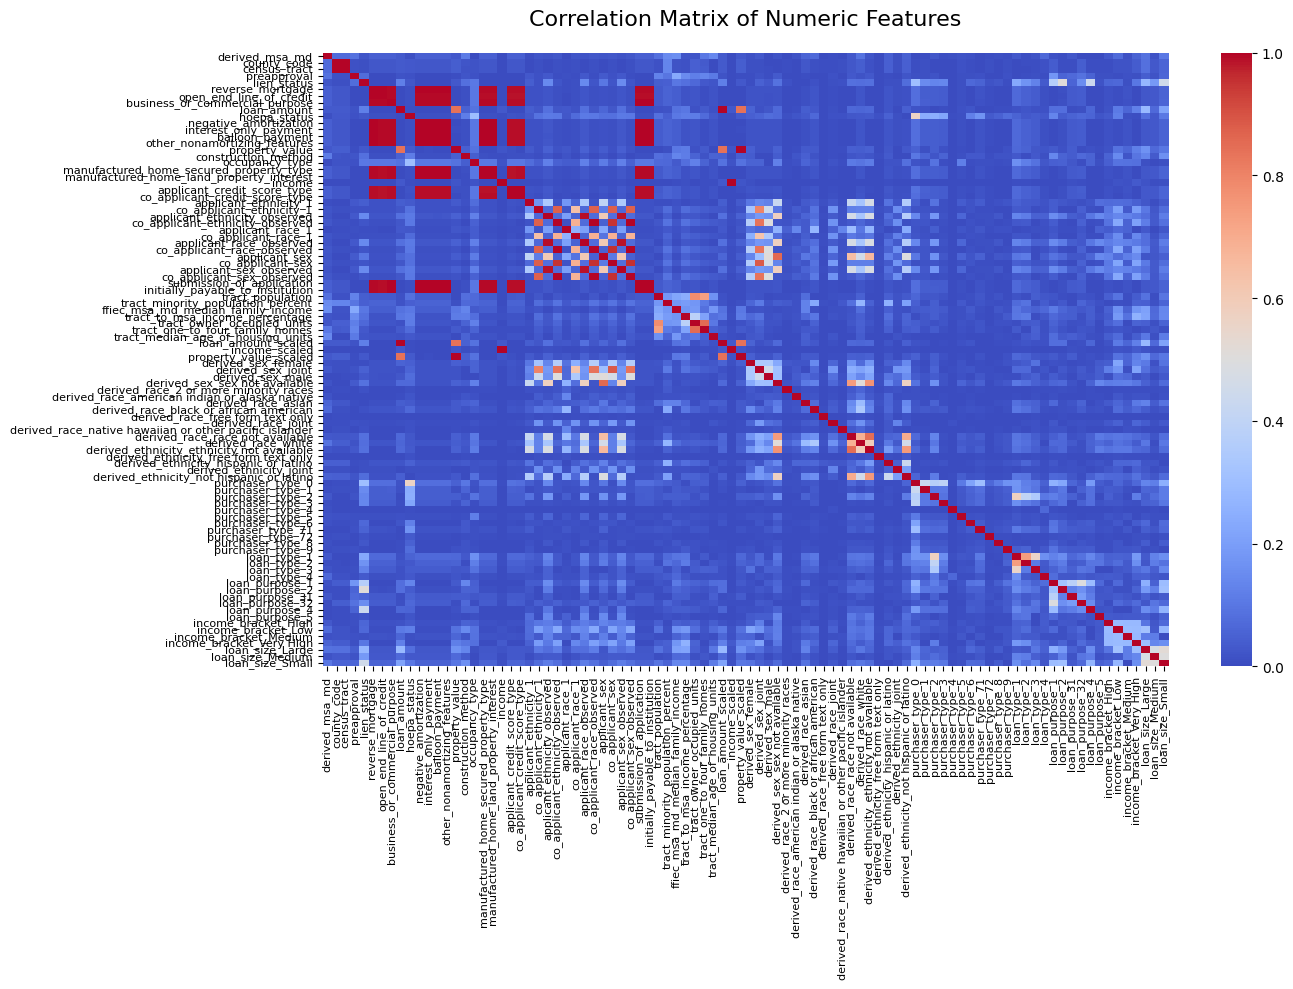


2. Menganalisis Variance Fitur (Tidak ada TARGET - Unsupervised)...
   ✓ Hanya menjaga fitur dengan variance > 0 (ada variasi)
   ✓ Menghapus fitur konstan (variance = 0)

Fitur dengan variance = 0 (KONSTAN): 0 fitur

Bentuk dataset final setelah feature selection:
  Sebelum: 99994 baris, 107 kolom
  Sesudah: 99994 baris, 80 kolom
  Kolom yang dihapus: 27 (applicant_credit_score_type, applicant_race_observed, applicant_sex_observed, balloon_payment, business_or_commercial_purpose...)

Dataset final berhasil disimpan di: ../data/processed/hmda_phase1_final.csv

✓ Fase 1 Selesai! Data siap untuk:
  - Clustering (Segmentation Specialist)
  - Anomaly & Outlier Detection (Data Analyst)
  - General Pattern Discovery


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Memulai Feature Selection untuk Clustering & Outlier Detection ---")
print("\n1. Menghitung Matriks Korelasi (Pearson)...")

# Ambil subset khusus kolom numerik
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64']).copy()

# A. Bersihkan nilai Infinite (ubah jadi NaN dulu agar aman)
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# B. Hapus kolom yang nilainya KONSTAN semua (variasi = 0)
# Kolom konstan membuat korelasi menjadi NaN dan merusak heatmap
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# Hitung korelasi dan ambil nilai mutlaknya (absolut)
corr_matrix = numeric_df.corr().abs()

# C. Jika masih ada NaN di matriks korelasi, paksa jadi 0 agar visualisasi tetap jalan
corr_matrix.fillna(0, inplace=True)

# Mencari pasangan fitur yang sangat berkorelasi (threshold > 0.8)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]

print(f"Fitur numerik yang redundan (>0.8): {high_corr_pairs}")

# Visualisasi Heatmap yang Diperbaiki
plt.figure(figsize=(14, 10))

# Kita atur vmin=0 dan vmax=1 karena nilai absolut korelasi maksimal adalah 1
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=0, vmax=1,
            xticklabels=True, yticklabels=True)

plt.title("Correlation Matrix of Numeric Features", fontsize=16, pad=20)
plt.xticks(rotation=90, fontsize=8) # Memutar label X agar terbaca
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout() # Mencegah label terpotong di pinggir layar
plt.show()

# 2. ANALISIS VARIANCE (Variability) untuk melihat fitur apa yang memiliki informasi
# Untuk clustering dan outlier detection (unsupervised), kita hanya perlu fitur dengan variance tinggi
print("\n2. Menganalisis Variance Fitur (Tidak ada TARGET - Unsupervised)...")
print("   ✓ Hanya menjaga fitur dengan variance > 0 (ada variasi)")
print("   ✓ Menghapus fitur konstan (variance = 0)")

# Hitung variance untuk setiap kolom numerik
variance_scores = numeric_df.var()
constant_features = variance_scores[variance_scores == 0].index.tolist()

print(f"\nFitur dengan variance = 0 (KONSTAN): {len(constant_features)} fitur")
if constant_features:
    print(f"  {constant_features}")

# 3. PENYIMPANAN FINAL - Hanya buang fitur redundan dan konstan
cols_to_drop_final = sorted(set(high_corr_pairs + constant_features))
df_final = df_cleaned.drop(columns=cols_to_drop_final, errors='ignore')

print(f"\nBentuk dataset final setelah feature selection:")
print(f"  Sebelum: {df_cleaned.shape[0]} baris, {df_cleaned.shape[1]} kolom")
print(f"  Sesudah: {df_final.shape[0]} baris, {df_final.shape[1]} kolom")
print(f"  Kolom yang dihapus: {len(cols_to_drop_final)} ({', '.join(cols_to_drop_final[:5]) + ('...' if len(cols_to_drop_final) > 5 else '')})")

# Simpan dataset akhir yang sudah siap dipakai untuk Fase 2 (Clustering) dan Fase 3 (Outlier Detection)
output_final_path = '../data/processed/hmda_phase1_final.csv'
df_final.to_csv(output_final_path, index=False)
print(f"\nDataset final berhasil disimpan di: {output_final_path}")
print("\n✓ Fase 1 Selesai! Data siap untuk:")
print("  - Clustering (Segmentation Specialist)")
print("  - Anomaly & Outlier Detection (Data Analyst)")
print("  - General Pattern Discovery")

In [6]:
print("--- Menampilkan Tabel Matriks Korelasi ---")

# 1. Menampilkan Matriks Utuh sebagai Tabel Berwarna
# Kita gunakan style.background_gradient agar tabelnya memiliki warna seperti heatmap
# Pastikan 'corr_matrix' dari kode sebelumnya sudah berjalan
styled_corr_table = corr_matrix.style.background_gradient(cmap='coolwarm', axis=None, vmin=0, vmax=1) \
                                     .format("{:.2f}") \
                                     .set_caption("Tabel Matriks Korelasi Fitur Kontinu HMDA") \
                                     .set_table_styles([{
                                         'selector': 'caption',
                                         'props': [('font-size', '16px'), ('font-weight', 'bold')]
                                     }])

# Menampilkan tabel di Jupyter Notebook
display(styled_corr_table)


# 2. Membuat Tabel Khusus Ekstraksi Redundansi (> 0.8)
# Ini adalah bonus untuk mempermudah kamu copy-paste ke Word/Laporan
print("\n--- Tabel Ringkasan Pasangan Fitur Redundan (> 0.8) ---")

# Mengambil nilai dari segitiga atas matriks agar tidak ada duplikasi
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Mengubah bentuk matriks menjadi format tabel panjang (kolom 1, kolom 2, nilai)
stacked_corr = upper_triangle.stack().reset_index()
stacked_corr.columns = ['Fitur 1', 'Fitur 2', 'Nilai Korelasi']

# Filter hanya yang nilai korelasinya di atas 0.8 dan urutkan dari yang tertinggi
redundant_table = stacked_corr[stacked_corr['Nilai Korelasi'] > 0.8].sort_values(by='Nilai Korelasi', ascending=False)
redundant_table = redundant_table.reset_index(drop=True)

# Menampilkan tabel ringkasan
if not redundant_table.empty:
    display(redundant_table)
    print("\nRekomendasi Tindakan: Kamu bisa memilih salah satu fitur dari setiap pasangan di atas untuk di-drop agar tidak memberatkan model Clustering nanti.")
else:
    print("Tidak ditemukan pasangan fitur dengan korelasi > 0.8.")

--- Menampilkan Tabel Matriks Korelasi ---


,derived_msa_md,county_code,census_tract,preapproval,lien_status,reverse_mortgage,open_end_line_of_credit,business_or_commercial_purpose,loan_amount,hoepa_status,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,income,applicant_credit_score_type,co_applicant_credit_score_type,applicant_ethnicity_1,co_applicant_ethnicity_1,applicant_ethnicity_observed,co_applicant_ethnicity_observed,applicant_race_1,co_applicant_race_1,applicant_race_observed,co_applicant_race_observed,applicant_sex,co_applicant_sex,applicant_sex_observed,co_applicant_sex_observed,submission_of_application,initially_payable_to_institution,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units,loan_amount_scaled,income_scaled,property_value_scaled,derived_sex_female,derived_sex_joint,derived_sex_male,derived_sex_sex not available,derived_race_2 or more minority races,derived_race_american indian or alaska native,derived_race_asian,derived_race_black or african american,derived_race_free form text only,derived_race_joint,derived_race_native hawaiian or other pacific islander,derived_race_race not available,derived_race_white,derived_ethnicity_ethnicity not available,derived_ethnicity_free form text only,derived_ethnicity_hispanic or latino,derived_ethnicity_joint,derived_ethnicity_not hispanic or latino,purchaser_type_0,purchaser_type_1,purchaser_type_2,purchaser_type_3,purchaser_type_4,purchaser_type_5,purchaser_type_6,purchaser_type_71,purchaser_type_72,purchaser_type_8,purchaser_type_9,loan_type_1,loan_type_2,loan_type_3,loan_type_4,loan_purpose_1,loan_purpose_2



--- Tabel Ringkasan Pasangan Fitur Redundan (> 0.8) ---


,Fitur 1,Fitur 2,Nilai Korelasi
0,loan_amount,loan_amount_scaled,1.000000
1,property_value,property_value_scaled,1.000000
2,income,income_scaled,1.000000
3,county_code,census_tract,1.000000
4,negative_amortization,other_nonamortizing_features,1.000000
...,...,...,...
101,loan_amount_scaled,property_value_scaled,0.836848
102,property_value,loan_amount_scaled,0.836848
103,co_applicant_sex_observed,derived_sex_joint,0.833639
104,co_applicant_race_observed,derived_sex_joint,0.832845



Rekomendasi Tindakan: Kamu bisa memilih salah satu fitur dari setiap pasangan di atas untuk di-drop agar tidak memberatkan model Clustering nanti.
